**Частина 1**

В якості домашнього завдання вам пропонується створити нейронну мережу за допомогою механізмів Keras, яка буде класифікувати товари із датасету fasion_mnist.

На відміну від попереднього завдання вам пропонується створити згорткову нейромережу. Підберіть архітектуру мережі та навчіть її на даних із датасету fasion_mnist. Спробуйте досягти максимально можливої точності класифікації за рахунок маніпуляції параметрами мережі. Порівняйте точність отриманої згорткової мережі з точністю багатошарової мережі з попереднього завдання. Зробіть висновки.

In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
from keras import models
from keras import layers
from sklearn.preprocessing import StandardScaler
from keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import time

In [4]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

In [7]:
X_train = X_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

y_train_one_hot = to_categorical(y_train,num_classes=10)

y_test_one_hot = to_categorical(y_test,num_classes=10)

In [8]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

time_start = time.time()

model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28, 28, 1),padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.BatchNormalization(),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,442 (947.04 KB)

 Trainable params: 241,994 (945.29 KB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
model.compile(loss='categorical_crossentropy', optimizer='nadam', metrics=['accuracy'])

In [10]:
# Add the checkpoint for best model
early_stopping = EarlyStopping(monitor='val_accuracy',patience=5,restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.h5',monitor='val_accuracy',mode='max',save_best_only=True,verbose=1)

In [11]:

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)
history = model.fit(datagen.flow(X_train, y_train_one_hot, batch_size=128),
    epochs=30,
    validation_data=(X_test, y_test_one_hot),  # or a held-out val split
    callbacks=[early_stopping, checkpoint, reduce_lr])

test_loss,test_accuracy = model.evaluate(X_test,y_test_one_hot)

print('Test accuracy: ', test_accuracy)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7126 - loss: 0.8021
Epoch 1: val_accuracy improved from None to 0.65230, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.7757 - loss: 0.6087 - val_accuracy: 0.6523 - val_loss: 0.9036 - learning_rate: 0.0010
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8331 - loss: 0.4441
Epoch 2: val_accuracy improved from 0.65230 to 0.86880, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - accuracy: 0.8398 - loss: 0.4292 - val_accuracy: 0.8688 - val_loss: 0.3628 - learning_rate: 0.0010
Epoch 3/30
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8588 - loss: 0.3815
Epoch 3: val_accuracy did not improve from 0.86880
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.8603 - loss: 0.3797 - val_accuracy: 0.8573 - val_loss: 0.3671 - learning_rate: 0.0010
Epoch 4/30
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8673 - loss: 0.3568
Epoch 4: val_accuracy improved from 0.86880 to 0.88210, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.8686 - loss: 0.3554 - val_accuracy: 0.8821 - val_loss: 0.3218 - learning_rate: 0.0010
Epoch 5/30
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8733 - loss: 0.3381
Epoch 5: val_accuracy improved from 0.88210 to 0.89490, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.8766 - loss: 0.3347 - val_accuracy: 0.8949 - val_loss: 0.2831 - learning_rate: 0.0010
Epoch 6/30
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8801 - loss: 0.3238
Epoch 6: val_accuracy improved from 0.89490 to 0.89680, saving model to best_model.h5


...


Epoch 10: finished saving model to best_model.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.9015 - loss: 0.2689 - val_accuracy: 0.9043 - val_loss: 0.2609 - learning_rate: 5.0000e-04
Epoch 11/30
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9052 - loss: 0.2568
Epoch 11: val_accuracy did not improve from 0.90430
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.9050 - loss: 0.2611 - val_accuracy: 0.8969 - val_loss: 0.2801 - learning_rate: 5.0000e-04
Epoch 12/30
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9061 - loss: 0.2574
Epoch 12: val_accuracy did not improve from 0.90430
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.9065 - loss: 0.2556 - val_accuracy: 0.8870 - val_loss: 0.3368 - learning_rate: 5.0000e-04
Epoch 13/30
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9112 - loss: 0.2419
Epoch 13: val_accuracy did not improve from 0.90430
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.9120 - loss: 0.2410 - val_accura


Epoch 14: finished saving model to best_model.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.9139 - loss: 0.2357 - val_accuracy: 0.9089 - val_loss: 0.2459 - learning_rate: 2.5000e-04
Epoch 15/30
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9144 - loss: 0.2353
Epoch 15: val_accuracy improved from 0.90890 to 0.90940, saving model to best_model.h5



Epoch 15: finished saving model to best_model.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.9151 - loss: 0.2342 - val_accuracy: 0.9094 - val_loss: 0.2540 - learning_rate: 2.5000e-04
Epoch 16/30
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9156 - loss: 0.2294
Epoch 16: val_accuracy did not improve from 0.90940
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.9146 - loss: 0.2302 - val_accuracy: 0.9044 - val_loss: 0.2627 - learning_rate: 2.5000e-04
Epoch 17/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9187 - loss: 0.2227
Epoch 17: val_accuracy improved from 0.90940 to 0.91030, saving model to best_model.h5



Epoch 17: finished saving model to best_model.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.9173 - loss: 0.2253 - val_accuracy: 0.9103 - val_loss: 0.2472 - learning_rate: 1.2500e-04
Epoch 18/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9173 - loss: 0.2272
Epoch 18: val_accuracy did not improve from 0.91030
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.9186 - loss: 0.2237 - val_accuracy: 0.9043 - val_loss: 0.2627 - learning_rate: 1.2500e-04
Epoch 19/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9191 - loss: 0.2191
Epoch 19: val_accuracy improved from 0.91030 to 0.91830, saving model to best_model.h5



Epoch 19: finished saving model to best_model.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.9204 - loss: 0.2169 - val_accuracy: 0.9183 - val_loss: 0.2337 - learning_rate: 6.2500e-05
Epoch 20/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9211 - loss: 0.2172
Epoch 20: val_accuracy did not improve from 0.91830
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.9197 - loss: 0.2174 - val_accuracy: 0.9148 - val_loss: 0.2364 - learning_rate: 6.2500e-05
Epoch 21/30
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9201 - loss: 0.2190
Epoch 21: val_accuracy did not improve from 0.91830
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.9211 - loss: 0.2155 - val_accuracy: 0.9143 - val_loss: 0.2361 - learning_rate: 6.2500e-05
Epoch 22/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9204 - loss: 0.2187
Epoch 22: val_accuracy did not improve from 0.91830
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.9214 - loss: 0.2145 - val_accura

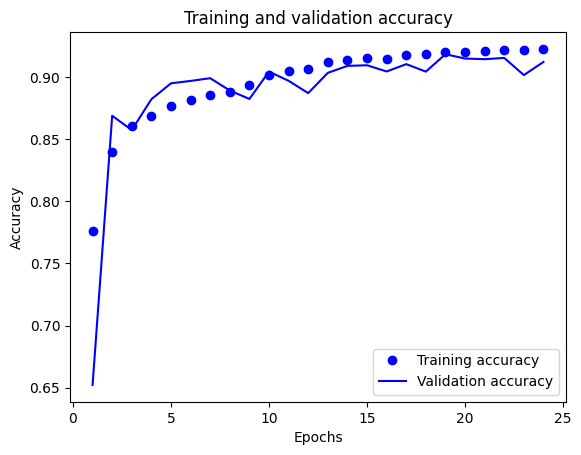

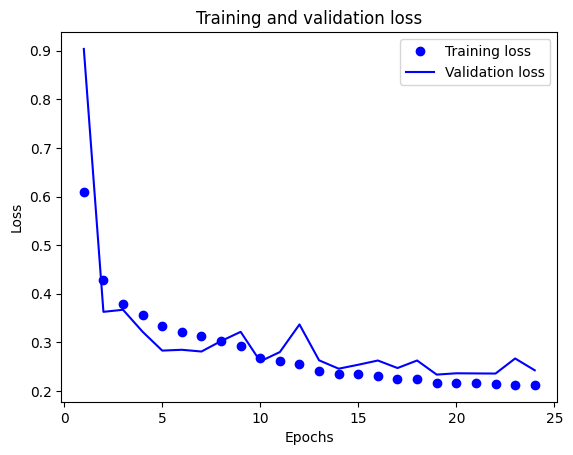

In [12]:
accuracy_values = history.history['accuracy']
val_accuracy_values = history.history['val_accuracy']

loss_values = history.history['loss']
val_loss_values = history.history['val_loss']

epochs = range(1,len(accuracy_values) + 1)

plt.plot(epochs, accuracy_values, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy_values, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

**Висновок**

Згорткова мережа показала точність 91.83% проти 90.11% у попередньої повнозв'язної мережі — приріст невеликий, але очікуваний. Різниця пояснюється тим, що CNN бачить зображення як зображення, а не як плаский набір пікселів, тому вловлює форми та контури речей краще.


**Частина 2**

В цій частині ми знову будемо працювати з датасетом fasion_mnist.

На відміну від попереднього завдання вам пропонується створити згорткову нейромережу, що використовує VGG16 в якості згорткової основи.

Навчіть отриману мережу на даних із датасету fasion_mnist. Спробуйте досягти максимально можливої точності класифікації за рахунок маніпуляції параметрами мережі. Під час навчання використовуйте прийоми донавчання та виділення ознак.
Порівняйте точність отриманої згорткової мережі з точністю багатошарової мережі з попереднього завдання. Зробіть висновки.


In [13]:
from tensorflow.keras.applications.vgg16 import VGG16

In [14]:
X_train_rgb = tf.image.resize(tf.image.grayscale_to_rgb(tf.constant(X_train)), (48, 48))
X_test_rgb = tf.image.resize(tf.image.grayscale_to_rgb(tf.constant(X_test)), (48, 48))

In [15]:
conv_base = VGG16(weights="imagenet", include_top=False,input_shape=(48, 48, 3))

model_vgg16 = models.Sequential([
    conv_base,
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax"),
])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:
model_vgg16.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 14,781,642 (56.39 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
conv_base.trainable = True
for layer in conv_base.layers:
    if layer.name not in ['block4_conv1','block4_conv2','block4_conv3','block5_conv1', 'block5_conv2', 'block5_conv3']:
        layer.trainable = False
    else:
        layer.trainable = True
model_vgg16.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Nadam(learning_rate=5e-6), metrics=['accuracy'])

In [18]:
train_features = conv_base.predict(X_train_rgb, batch_size=128, verbose=1)
test_features = conv_base.predict(X_test_rgb, batch_size=128, verbose=1)

469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step


In [19]:
early_stopping_vgg16 = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
checkpoint_vgg16 = ModelCheckpoint('best_model_vgg16.h5', monitor='val_accuracy', mode='max', save_best_only=True, verbose=1)
reduce_lr_vgg16 = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

In [20]:
datagen.fit(X_train_rgb)
history_vgg16 = model_vgg16.fit(datagen.flow(X_train_rgb, y_train_one_hot, batch_size=128),
    epochs=30,
    validation_data=(X_test_rgb, y_test_one_hot),
    callbacks=[early_stopping_vgg16, checkpoint_vgg16, reduce_lr_vgg16])

test_loss,test_accuracy = model_vgg16.evaluate(X_test_rgb,y_test_one_hot)

print('Test accuracy: ', test_accuracy)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.5613 - loss: 1.2825
Epoch 1: val_accuracy improved from None to 0.85960, saving model to best_model_vgg16.h5



Epoch 1: finished saving model to best_model_vgg16.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 93s 174ms/step - accuracy: 0.7211 - loss: 0.8213 - val_accuracy: 0.8596 - val_loss: 0.3921 - learning_rate: 5.0000e-06
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.8372 - loss: 0.4665
Epoch 2: val_accuracy improved from 0.85960 to 0.87800, saving model to best_model_vgg16.h5



Epoch 2: finished saving model to best_model_vgg16.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 124s 153ms/step - accuracy: 0.8437 - loss: 0.4498 - val_accuracy: 0.8780 - val_loss: 0.3394 - learning_rate: 5.0000e-06
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.8583 - loss: 0.4026
Epoch 3: val_accuracy improved from 0.87800 to 0.88120, saving model to best_model_vgg16.h5



Epoch 3: finished saving model to best_model_vgg16.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 73s 155ms/step - accuracy: 0.8629 - loss: 0.3917 - val_accuracy: 0.8812 - val_loss: 0.3280 - learning_rate: 5.0000e-06
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.8723 - loss: 0.3627
Epoch 4: val_accuracy improved from 0.88120 to 0.89400, saving model to best_model_vgg16.h5



Epoch 4: finished saving model to best_model_vgg16.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 72s 154ms/step - accuracy: 0.8745 - loss: 0.3570 - val_accuracy: 0.8940 - val_loss: 0.2921 - learning_rate: 5.0000e-06
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.8800 - loss: 0.3396
Epoch 5: val_accuracy improved from 0.89400 to 0.89760, saving model to best_model_vgg16.h5


...


Epoch 16: finished saving model to best_model_vgg16.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 71s 152ms/step - accuracy: 0.9158 - loss: 0.2348 - val_accuracy: 0.9171 - val_loss: 0.2289 - learning_rate: 2.5000e-06
Epoch 17/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.9198 - loss: 0.2257
Epoch 17: val_accuracy improved from 0.91710 to 0.91980, saving model to best_model_vgg16.h5



Epoch 17: finished saving model to best_model_vgg16.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 72s 153ms/step - accuracy: 0.9190 - loss: 0.2292 - val_accuracy: 0.9198 - val_loss: 0.2252 - learning_rate: 2.5000e-06
Epoch 18/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.9199 - loss: 0.2263
Epoch 18: val_accuracy did not improve from 0.91980
469/469 ━━━━━━━━━━━━━━━━━━━━ 73s 155ms/step - accuracy: 0.9189 - loss: 0.2279 - val_accuracy: 0.9176 - val_loss: 0.2303 - learning_rate: 2.5000e-06
Epoch 19/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.9223 - loss: 0.2199
Epoch 19: val_accuracy improved from 0.91980 to 0.92120, saving model to best_model_vgg16.h5



Epoch 19: finished saving model to best_model_vgg16.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 72s 154ms/step - accuracy: 0.9206 - loss: 0.2223 - val_accuracy: 0.9212 - val_loss: 0.2247 - learning_rate: 2.5000e-06
Epoch 20/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9215 - loss: 0.2227
Epoch 20: val_accuracy did not improve from 0.92120
469/469 ━━━━━━━━━━━━━━━━━━━━ 72s 154ms/step - accuracy: 0.9199 - loss: 0.2240 - val_accuracy: 0.9201 - val_loss: 0.2230 - learning_rate: 2.5000e-06
Epoch 21/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.9228 - loss: 0.2163
Epoch 21: val_accuracy did not improve from 0.92120
469/469 ━━━━━━━━━━━━━━━━━━━━ 73s 155ms/step - accuracy: 0.9210 - loss: 0.2199 - val_accuracy: 0.9192 - val_loss: 0.2267 - learning_rate: 2.5000e-06
Epoch 22/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9213 - loss: 0.2198
Epoch 22: val_accuracy did not improve from 0.92120
469/469 ━━━━━━━━━━━━━━━━━━━━ 72s 154ms/step - accuracy: 0.9212 - loss: 0.2198


Epoch 24: finished saving model to best_model_vgg16.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 72s 154ms/step - accuracy: 0.9232 - loss: 0.2123 - val_accuracy: 0.9230 - val_loss: 0.2167 - learning_rate: 2.5000e-06
Epoch 25/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9220 - loss: 0.2157
Epoch 25: val_accuracy did not improve from 0.92300
469/469 ━━━━━━━━━━━━━━━━━━━━ 72s 154ms/step - accuracy: 0.9234 - loss: 0.2115 - val_accuracy: 0.9211 - val_loss: 0.2211 - learning_rate: 2.5000e-06
Epoch 26/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.9252 - loss: 0.2062
Epoch 26: val_accuracy did not improve from 0.92300
469/469 ━━━━━━━━━━━━━━━━━━━━ 71s 152ms/step - accuracy: 0.9243 - loss: 0.2099 - val_accuracy: 0.9197 - val_loss: 0.2216 - learning_rate: 2.5000e-06
Epoch 27/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.9270 - loss: 0.2041
Epoch 27: val_accuracy did not improve from 0.92300
469/469 ━━━━━━━━━━━━━━━━━━━━ 73s 155ms/step - accuracy: 0.9277 - loss: 0.2033


Epoch 28: finished saving model to best_model_vgg16.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 74s 158ms/step - accuracy: 0.9268 - loss: 0.2019 - val_accuracy: 0.9241 - val_loss: 0.2165 - learning_rate: 1.2500e-06
Epoch 29/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.9261 - loss: 0.2033
Epoch 29: val_accuracy did not improve from 0.92410
469/469 ━━━━━━━━━━━━━━━━━━━━ 72s 154ms/step - accuracy: 0.9269 - loss: 0.2029 - val_accuracy: 0.9238 - val_loss: 0.2158 - learning_rate: 1.2500e-06
Epoch 30/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.9260 - loss: 0.2026
Epoch 30: val_accuracy did not improve from 0.92410
469/469 ━━━━━━━━━━━━━━━━━━━━ 74s 158ms/step - accuracy: 0.9273 - loss: 0.2003 - val_accuracy: 0.9217 - val_loss: 0.2179 - learning_rate: 1.2500e-06
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9241 - loss: 0.2165
Test accuracy:  0.9240999817848206


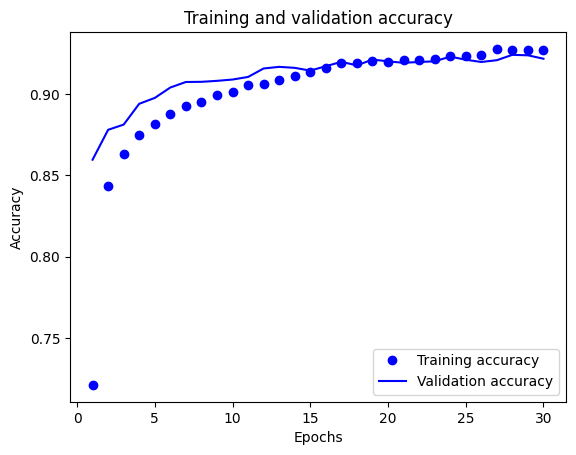

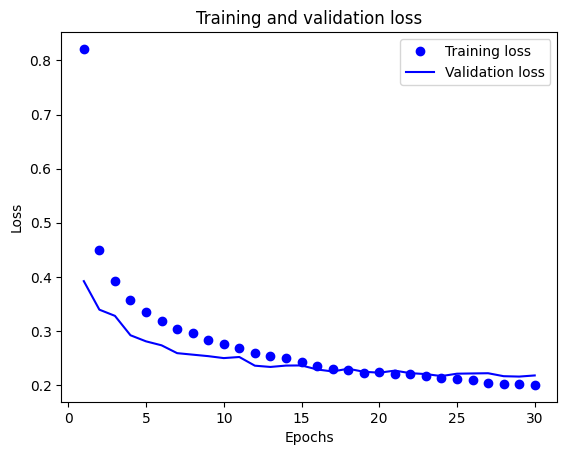

In [21]:
accuracy_values_vgg16 = history_vgg16.history['accuracy']
val_accuracy_values_vgg16 = history_vgg16.history['val_accuracy']

loss_values_vgg16 = history_vgg16.history['loss']
val_loss_values_vgg16 = history_vgg16.history['val_loss']

epochs_vgg16 = range(1,len(accuracy_values_vgg16) + 1)

plt.plot(epochs_vgg16, accuracy_values_vgg16, 'bo', label='Training accuracy')
plt.plot(epochs_vgg16, val_accuracy_values_vgg16, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(epochs_vgg16, loss_values_vgg16, 'bo', label='Training loss')
plt.plot(epochs_vgg16, val_loss_values_vgg16, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

**Висновок**

VGG16 із донавчанням дала 92.41% — трохи краще за власну CNN (91.83%), але не значний стрибок. Спочатку, з повністю замороженою базою , точність трималась на рівні близько 85%, а після розморожування block4 і block5 з дуже малим learning rate вона піднялась до 92.41% — тобто саме донавчання дало приріст майже у 7 відсоткових пунктів.

